In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

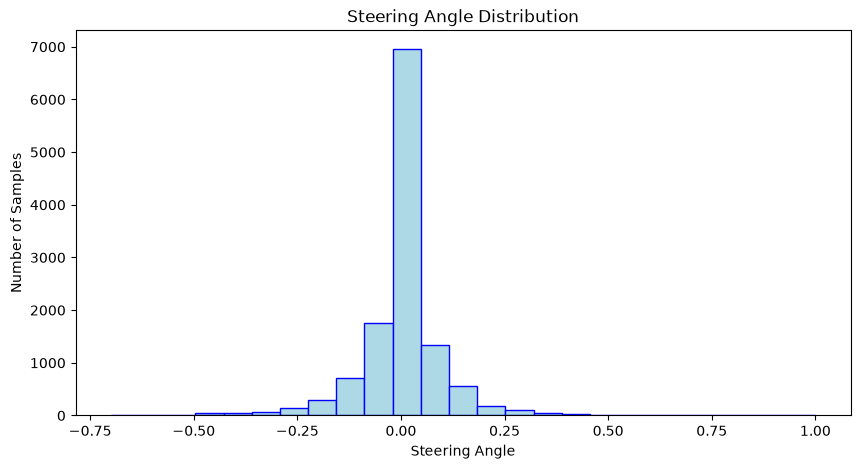

In [ ]:
#1. read data
# Note: The CSV from Udacity doesn't have headers, so use names=columns.
columns = ['Center', 'Left', 'Right', 'Steering', 'Throttle', 'Brake', 'Speed']
data = pd.read_csv('driving_log.csv', names=columns)

#2. Will use only the center camera images and the steering angle
center_images = data['Center'].values
steering_angles = data['Steering'].values

#3. Plot the histogram to check the data balance
num_bins = 25
plt.figure(figsize=(10, 5))
hist, bins, _ = plt.hist(steering_angles, bins=num_bins, color='lightblue', edgecolor='blue')
plt.title('Steering Angle Distribution')
plt.xlabel('Steering Angle')
plt.ylabel('Number of Samples')
plt.show()

# NOTE: If the histogram shows a massive spike at 0.0 (driving straight),
# you will need to write logic here to drop a percentage of those 0.0 values to flatten/balance the histogram

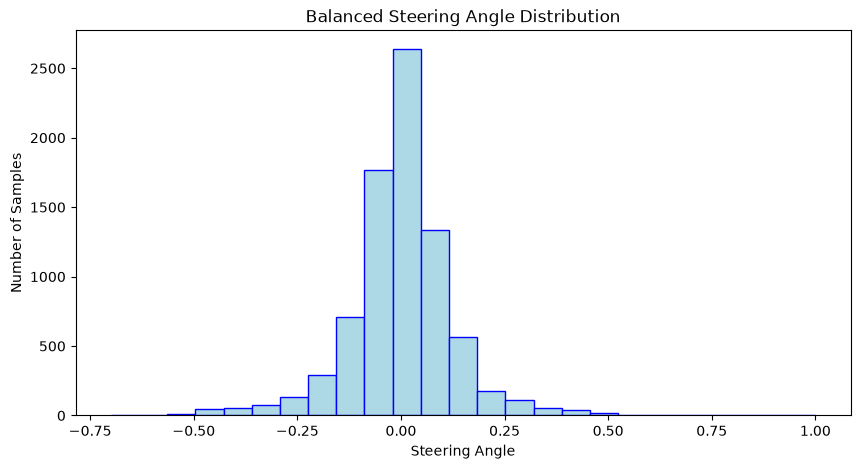

Original Total Images: 12365
Balanced Total Images: 8044


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns = ['Center', 'Left', 'Right', 'Steering', 'Throttle', 'Brake', 'Speed']
data = pd.read_csv('driving_log.csv', names=columns)

# get all rows that the steering angle is 0.0
zero_steering = data[data['Steering'] == 0.0]

# randomly select a percentage to drop
# dropping 80% of the 0.0 values (frac=0.8)
drop_indices = zero_steering.sample(frac=0.8, random_state=42).index

# create a new dataframe by dropping the indices (balanced version)
balanced_data = data.drop(drop_indices)
# ==========================================

# use the newly balanced data for your arrays
center_images = balanced_data['Center'].values
steering_angles = balanced_data['Steering'].values

plt.figure(figsize=(10, 5))
plt.hist(steering_angles, bins=num_bins, color='lightblue', edgecolor='blue')
plt.title('Balanced Steering Angle Distribution')
plt.xlabel('Steering Angle')
plt.ylabel('Number of Samples')
plt.show()

# removed data comparison
print(f"Original Total Images: {len(data)}")
print(f"Balanced Total Images: {len(balanced_data)}")